In [15]:
#the wing we are designing is bounded by 3 criterion based upon the wind tunnel available,
#the max velocity we can achieve is around 40 m/s and our wind tunnel section has a width of
#1600 mm or 1.6 meters to achieve an aspect ratio similar to the goland wing of 12 we will 
#also have a chord constraint to scale relative to our span, the goland wing is roughly 6.1 
#metres by 1.8 metres

import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

u_inf = 20.
alpha_deg = 8.  # Define angle of attack for static aeroelastic analysis.
rho = 1.225      # Air density. #inquire about this for our wind tunnel

M = 16             # Number of chordwise panels
N = 32             # Number of spanwise panels
M_star_fact = 10   # Length of the wake in chords.
num_modes =  8     # Number of vibration modes retained in the structural model.

c_ref = .2 
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

case_name = 'mycase7'
route_test_dir = os.path.abspath('')

print('The case to run will be: %s' % case_name)
print('Case files will be saved in ./cases/%s' %case_name)
print('Output files will be saved in ./output/%s/' %case_name)

#let us assume we are making a wing that is half the size, thus let us set our b_ref to 1.2 metres
#to achieve an aspect ratio of 12 we need 2*1.2/x = 12 leading to our chord of 0.2 metres

#the elastic axis is at 0.33 chord and the main cg is at 0.43 chord as per the goland wing

length = .5
ws = wings.Goland(M=M,
                  N=N,
                  Mstar_fact=M_star_fact,
                  u_inf=u_inf,
                  alpha=alpha_deg,
                  rho=rho,
                  b_ref=2. * length,
                  main_chord= 0.2,
                  aspect_ratio=(2. * length) / 0.2,
                  sweep=0,
                  physical_time=2,
                  n_surfaces=2,
                  route = route_test_dir + '/cases',
                  case_name=case_name
                  )

def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    width = 50E-3
    height = 2E-3
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = 1.42 #7
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

ws.update_mass_stiff = new_update_mass_stiff.__get__(ws, wings.Goland)   

ws.clean_test_files()
ws.update_derived_params()
ws.set_default_config_dict()

ws.generate_aero_file()
ws.generate_fem_file()

The case to run will be: mycase7
Case files will be saved in ./cases/mycase7
Output files will be saved in ./output/mycase7/
3.333333333333334e-11
2.0833333333333338e-08
[[6.90000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.60000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.60000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.93333333e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.30000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.43750000e+03]]
2.086666666666667e-08
5.634000000000001e-05


In [16]:
ws.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': ws.case_name, 'route': ws.route,
    'write_screen': 'on', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': ws.case_name + '.log'}

ws.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': ws.quat}

ws.config['AerogridLoader'] = {
    'unsteady': 'off',
    'aligned_grid': 'on',
    'mstar': ws.Mstar_fact * ws.M,
    'freestream_dir': ws.u_inf_direction,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {'u_inf': ws.u_inf,
                                    'u_inf_direction': ws.u_inf_direction,
                                    'dt': ws.dt}}

ws.config['StaticCoupled'] = {
    'print_info': 'on',
    'max_iter': 200,
    'n_load_steps': 1,
    'tolerance': 1e-10,
    'relaxation_factor': 0.,
    'aero_solver': 'StaticUvlm',
    'aero_solver_settings': {
        'rho': ws.rho,
        'print_info': 'off',
        'horseshoe': 'off',
        'num_cores': 4,
        'n_rollup': 0,
        'rollup_dt': ws.dt,
        'rollup_aic_refresh': 1,
        'rollup_tolerance': 1e-4,
        'velocity_field_generator': 'SteadyVelocityField',
        'velocity_field_input': {
            'u_inf': ws.u_inf,
            'u_inf_direction': ws.u_inf_direction}},
    'structural_solver': 'NonLinearStatic',
    'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 150,
                                   'num_load_steps': 4,
                                   'delta_curved': 1e-1,
                                   'min_delta': 1e-10,
                                   'gravity_on': 'on',
                                   'gravity': 9.81}}

ws.config['AerogridPlot'] = {'include_rbm': 'off',
                             'include_applied_forces': 'on',
                             'minus_m_star': 0}

ws.config['BeamPlot'] = {'include_rbm': 'off',
                         'include_applied_forces': 'on'}

ws.config['Modal'] = {'NumLambda': 20,
                      'rigid_body_modes': 'off',
                      'print_matrices': 'on', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                      'rigid_modes_cg': 'off',
                      'continuous_eigenvalues': 'off',
                      'dt': 0,
                      'plot_eigenvalues': False,
                      'max_rotation_deg': 15.,
                      'max_displacement': 0.15,
                      'write_modes_vtk': True,
                      'use_undamped_modes': True}

ws.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': 'on',
                                                      'inout_coords': 'modes',
                                                      'discrete_time': 'on',
                                                      'newmark_damp': 0.5e-4,
                                                      'discr_method': 'newmark',
                                                      'dt': ws.dt,
                                                      'proj_modes': 'undamped',
                                                      'use_euler': 'off',
                                                      'num_modes': num_modes,
                                                      'print_info': 'on',
                                                      'gravity': 'on',
                                                      'remove_sym_modes': 'on',
                                                      'remove_dofs': []},
                                    'aero_settings': {'dt': ws.dt,
                                                      'ScalingDict': {'length': 0.5 * ws.c_ref,
                                                                      'speed': u_inf,
                                                                      'density': rho},
                                                      'integr_order': 2,
                                                      'density': ws.rho,
                                                      'remove_predictor': 'on',
                                                      'use_sparse': 'on',
                                                      'remove_inputs': ['u_gust'],
                                                      'rom_method': ['Krylov'],
                                                      'rom_method_settings': {'Krylov': rom_settings}},
                                    }}

ws.config['AsymptoticStability'] = {'print_info': True,
                                    'velocity_analysis': [10, 100, 81],
                                   'modes_to_plot': []}
                                    

ws.config.write()

In [17]:
sharpy_output = sharpy.sharpy_main.main(['', ws.route + ws.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/user/sharpy/sharpy
SHARPy being run is in /home/user/.local/lib/python3.10/site-packages
SHARPy output folder set
	/home/user/sharpy/sharpy/output//mycase7/
Gen

fatal: not a git repository (or any of the parent directories): .git


|  0  |  0  |  0.00000   |  0.0008  |  0.0000  | 13.5749  |  0.0000  |  3.0158  |  0.0000  |
|  1  |  0  |  -3.22485  | -1.3023  |  0.0000  | 20.4678  | -0.0000  |  3.0720  |  0.0000  |
|  2  |  0  |  -5.01128  | -1.3248  |  0.0000  | 20.5810  | -0.0000  |  3.0781  | -0.0000  |
|  3  |  0  |  -5.55384  | -1.3291  |  0.0000  | 20.6010  | -0.0000  |  3.0781  | -0.0000  |
|  4  |  0  |  -6.89696  | -1.3291  |  0.0000  | 20.6007  | -0.0000  |  3.0781  | -0.0000  |
|  5  |  0  |  -7.89367  | -1.3291  |  0.0000  | 20.6007  | -0.0000  |  3.0781  | -0.0000  |
|  6  |  0  |  -9.08320  | -1.3291  |  0.0000  | 20.6007  | -0.0000  |  3.0781  | -0.0000  |
|  7  |  0  | -10.17887  | -1.3291  |  0.0000  | 20.6007  | -0.0000  |  3.0781  | -0.0000  |
Generating an instance of AerogridPlot
Variable include_forward_motion has no assigned value in the settings file.
    will default to the value: False
Variable include_unsteady_applied_forces has no assigned value in the settings file.
    will default to

/home/user/.local/lib/python3.10/site-packages/sharpy/solvers/modal.py:289: RuntimeWarning: invalid value encountered in sqrt
  freq_natural = np.sqrt(eigenvalues)


|      0       |   0.000000   |  16.603129   |   2.642470   |   2.642470   |  -0.000000   |   0.378434   |
|      1       |   0.000000   |  16.605343   |   2.642822   |   2.642822   |  -0.000000   |   0.378383   |
|      2       |   0.000000   |  87.483351   |  13.923408   |  13.923408   |  -0.000000   |   0.071821   |
|      3       |   0.000000   |  87.494518   |  13.925185   |  13.925185   |  -0.000000   |   0.071812   |
|      4       |   0.000000   |  205.822275  |  32.757632   |  32.757632   |  -0.000000   |   0.030527   |
|      5       |   0.000000   |  205.834378  |  32.759559   |  32.759559   |  -0.000000   |   0.030525   |
|      6       |   0.000000   |  353.629775  |  56.281927   |  56.281927   |  -0.000000   |   0.017768   |
|      7       |   0.000000   |  353.650128  |  56.285166   |  56.285166   |  -0.000000   |   0.017767   |
|      8       |   0.000000   |  449.729538  |  71.576679   |  71.576679   |  -0.000000   |   0.013971   |
|      9       |   0.000000   |  449.

/home/user/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


	state-space model produced in form:
			h_{n+1} = A h_{n} + B u_{n}
			with:
	x_n = h_n + Bp u_n
			...done in 24.06 sec
Scaling UVLM system with reference time 0.045720s
Non-dimensional time step set (0.013670)
System scaled in 48.232502s
Generating an instance of LinearBeam
Variable remove_rigid_states has no assigned value in the settings file.
    will default to the value: False
Warning, projecting system with damping onto undamped modes


/home/user/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '
/home/user/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:1217: RuntimeWarning: invalid value encountered in sqrt
  omega = np.sqrt(eigenvalues)



Linearising gravity terms...
	M = 0.00 kg
	X_CG A -> -2583.86 1644.72 21.58
Node  1 	-> B -0.000 -0.116 -0.002
			-> A 0.116 0.031 -0.003
			-> G 0.115 0.031 -0.019
	Node mass:
		Matrix: 0.0473
Node  2 	-> B -0.000 -0.116 -0.005
			-> A 0.116 0.062 -0.004
			-> G 0.115 0.062 -0.020
	Node mass:
		Matrix: 0.0237
Node  3 	-> B -0.001 -0.117 -0.006
			-> A 0.116 0.094 -0.005
			-> G 0.115 0.094 -0.021
	Node mass:
		Matrix: 0.0473
Node  4 	-> B -0.001 -0.117 -0.008
			-> A 0.116 0.125 -0.004
			-> G 0.115 0.125 -0.020
	Node mass:
		Matrix: 0.0237
Node  5 	-> B -0.001 -0.117 -0.009
			-> A 0.117 0.156 -0.003
			-> G 0.115 0.156 -0.019
	Node mass:
		Matrix: 0.0473
Node  6 	-> B -0.001 -0.117 -0.010
			-> A 0.117 0.187 -0.001
			-> G 0.115 0.187 -0.017
	Node mass:
		Matrix: 0.0237
Node  7 	-> B -0.002 -0.117 -0.011
			-> A 0.117 0.218 0.002
			-> G 0.116 0.218 -0.014
	Node mass:
		Matrix: 0.0473
Node  8 	-> B -0.002 -0.117 -0.011
			-> A 0.117 0.249 0.005
			-> G 0.116 0.249 -0.011
	Node mass

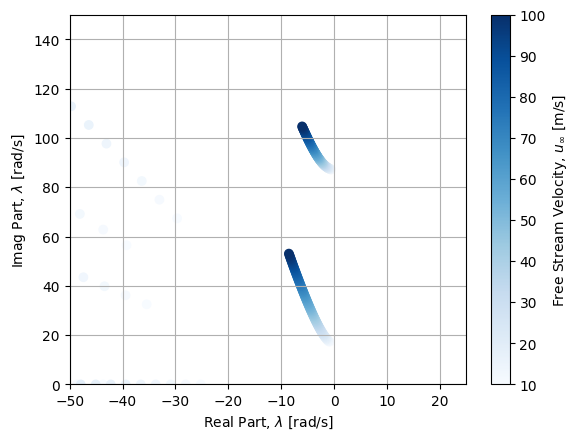

In [18]:
file_name = './output/%s/stability/velocity_analysis_min0100_max1000_nvel0081.dat' % case_name
%matplotlib inline
velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

fig = plt.figure()
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-50, 25)
plt.ylim(0, 150)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

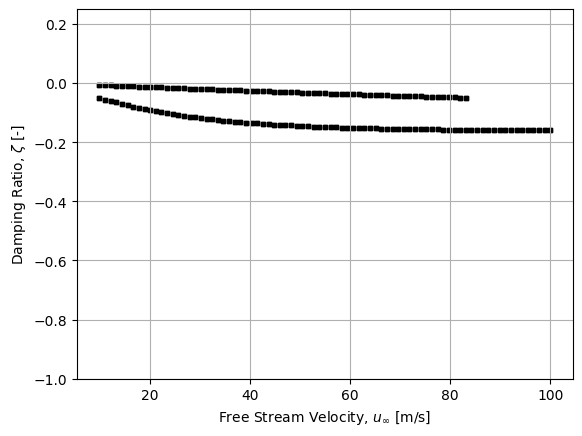

In [19]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)

plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)

plt.grid()
plt.ylim(-1, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

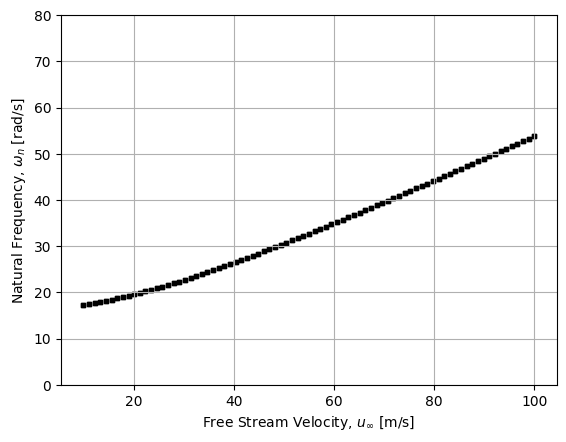

In [20]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)
plt.grid()
plt.ylim(0, 80)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');

6.666666666666668e-11
16.79203526574231


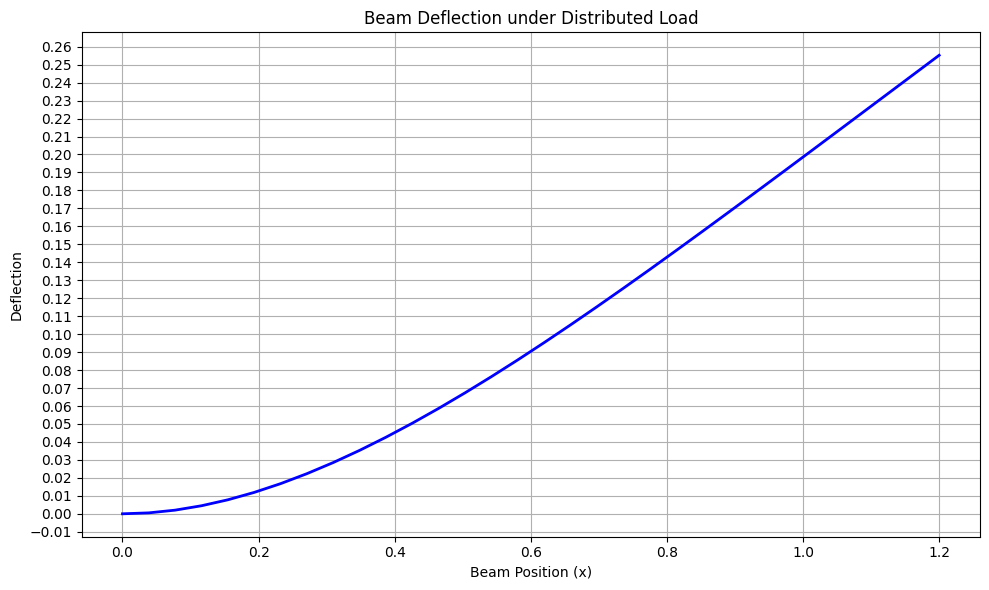

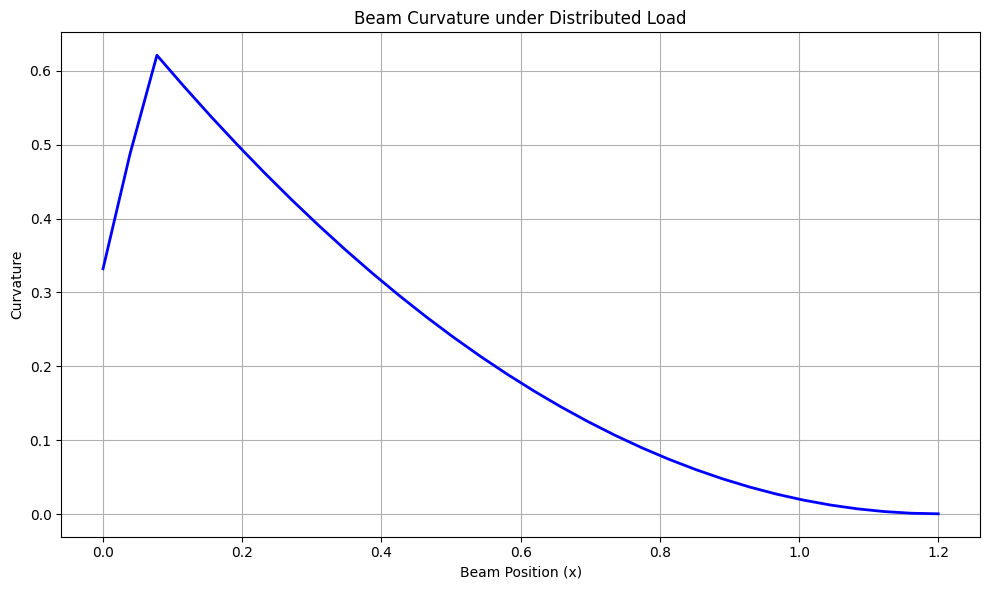

In [21]:
import numpy as np

# Constants
rho = 1.225  # air density (kg/m^3) at atmospheric conditions
V = 25 # velocity (m/s)
chord = 0.2  # chord length (m)
span = 1.2  # span (m)
width = 0.1  # beam width (m)
height = 0.002  # beam height (m)
E = 69e9  # Young's modulus for aluminum (Pa)
I = (width * height**3) / 12  # moment of inertia (m^4)
print(I)
CL = 2*np.pi  # Adjusted lift coefficient for NACA 0012 at 2 degrees AoA
aoa = np.radians(2)  # angle of attack in radians

# Aerodynamic forces
q = 0.5 * rho * V**2  # dynamic pressure (Pa)
L_per_span = q * CL * aoa * chord  # lift per unit span (N/m)
print(L_per_span)

# Beam deflection
x = np.linspace(0,span,N)
deflection = (((L_per_span - 9.81*1.25) * x**2) / (24 * E * I)) * (x**2 + 6 * span**2 - 4 * span * x)

plt.figure(figsize=(10, 6))
plt.plot(x, deflection, 'b-', linewidth=2)
plt.title('Beam Deflection under Distributed Load')
plt.xlabel('Beam Position (x)')
plt.ylabel('Deflection')
plt.grid(True)
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(0.01))
plt.tight_layout()
plt.show()

d_deflection_dx = np.gradient(deflection, x)
d2_deflection_dx2 = np.gradient(d_deflection_dx, x)
plt.figure(figsize=(10, 6))
plt.plot(x, d2_deflection_dx2, 'b-', linewidth=2)
plt.title('Beam Curvature under Distributed Load')
plt.xlabel('Beam Position (x)')
plt.ylabel('Curvature')
plt.grid(True)
plt.tight_layout()
plt.show()

